In [194]:
import os
from typing import TypedDict, Annotated

from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import END
from langgraph.constants import START
from langgraph.graph import StateGraph
from langgraph.graph import add_messages
from pydantic import BaseModel, Field
from langgraph.prebuilt import ToolNode

load_dotenv()


True

In [195]:

class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [196]:
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch

search_tool = TavilySearch(
    max_results=1,
    topic="general",
    include_images=False,
    search_depth="basic"
)

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.4, reasoning_format="hidden")
llm_with_tool = llm.bind_tools([search_tool])


In [197]:
from langchain_openai import ChatOpenAI

CEREBRAS_API_KEY = os.getenv("CEREBRAS_API_KEY")

cerebras_llm = ChatOpenAI(
    model="zai-glm-4.7",
    base_url="https://api.cerebras.ai/v1",
    temperature=0.4,
    reasoning_effort="high",
    api_key=CEREBRAS_API_KEY
)

cerebras_llm_with_tool = cerebras_llm.bind_tools([search_tool])


In [198]:


class OutputParser(BaseModel):
    response: str = Field(description="Response returned by LLM in string format")


cerebras_llm_with_tool_structured = cerebras_llm.with_structured_output(OutputParser)

In [199]:
def chat_node(state: State) -> State:
    response_llm = cerebras_llm_with_tool.invoke(input=state["messages"])
    return {"messages": [response_llm]}

In [200]:

tool_node = ToolNode([search_tool])

In [201]:
from langchain_core.messages import ToolMessage


def should_continue(state: State) -> str:
    """Determine if we should continue or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]

    # If no tools were called, we're done
    if not last_message.tool_calls:
        return "end"
    else:
        return "tool_node"

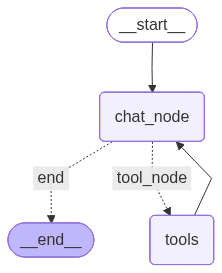

In [202]:
checkpointer = InMemorySaver()
config = {"configurable": {"thread_id": "thread_1"}}

graph = StateGraph(State)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", should_continue, {"tool_node": "tools", "end": END})
graph.add_edge("tools", "chat_node")
graph.add_edge("chat_node", END)

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [205]:
from langchain_core.messages import SystemMessage
from IPython.display import Markdown

system_message = SystemMessage(content="You are a helpful assistant with tools. Please use the tools to answer the user's questions. \
Only and only the final response to Human should be in well structured markdown format.")
human_message = HumanMessage(content= "What is the next match of fifa 2026")


result = workflow.invoke(input={"messages": [human_message]}, config=config)
Markdown(result["messages"][-1].content)

Based on the search results, here's what I can tell you about the FIFA World Cup 2026:

**The opening match of FIFA World Cup 2026 will take place on June 11, 2026** at Estadio Azteca in Mexico City.

Here are the key details:
- **Date:** June 11, 2026
- **Venue:** Estadio Azteca, Mexico City
- **Opening Ceremony:** Will feature performances by Shakira and Burna Boy with the official World Cup song "Dai Dai"
- **Time:** The ceremony will begin ahead of the opening match

The 2026 FIFA World Cup will be hosted by three countries: **Mexico, Canada, and the United States**, making it the first World Cup to be hosted by multiple nations. There will be opening ceremonies for each host country on June 11-12, 2026, with Mexico hosting the main opening ceremony and first match.

However, the specific teams playing in the opening match haven't been announced yet, as the tournament draw and schedule details are still being finalized by FIFA.

Since the tournament is still about a year away (as of 2025), this will be the first/next match when the World Cup begins!